### 多项式回归升维实战（一）

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

#### 创建数据

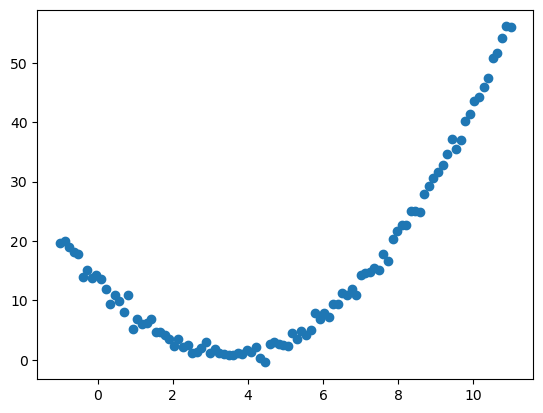

In [2]:
X = np.linspace(-1,11,num=100)
y = (X-5)**2+3*X-12+np.random.randn(100)
X = X.reshape(-1,1)

plt.scatter(X,y)

#### 使用线性回归预测

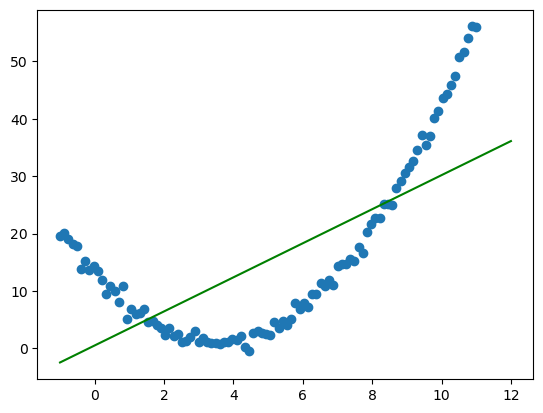

In [3]:
#数据训练
model = LinearRegression()
model.fit(X,y)

#数据预测
X_test = np.linspace(-1,12,300).reshape(-1,1)

y_pred = model.predict(X_test)

plt.scatter(X,y)
plt.plot(X_test,y_pred,color = "green")

#### 使用升维

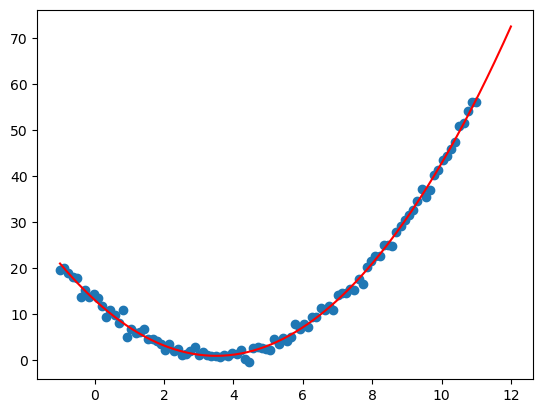

In [4]:
np.set_printoptions(suppress=True)
X2 = np.concatenate([X,X**2],axis = 1)

model2 = LinearRegression()
model2.fit(X2,y)

X_test2 = np.concatenate([X_test,X_test**2],axis = 1)
y_pred = model2.predict(X_test2)

plt.scatter(X,y)
plt.plot(X_test,y_pred,color='red')

### 多项式回归升维实战（二）

In [5]:
from sklearn.linear_model import LinearRegression
#PolynomialFeature,就是升维
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
import numpy as np


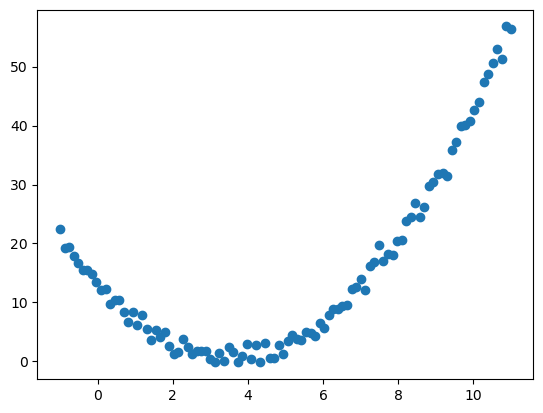

In [6]:
X = np.linspace(-1,11,num=100)
y = (X-5)**2+3*X-12+np.random.randn(100)
X = X.reshape(-1,1)
plt.scatter(X,y)

In [7]:
X_test = np.linspace(-1,12,300).reshape(-1,1)

In [8]:
poly = PolynomialFeatures(degree=2)
X2 = poly.fit_transform(X)
X_test2 = poly.fit_transform(X_test)

In [9]:
model = LinearRegression()
model.fit(X2,y)

y_pred2 = model.predict(X_test2)

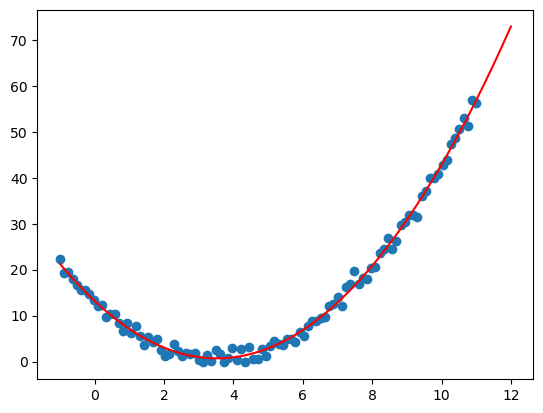

In [10]:
plt.scatter(X,y)
plt.plot(X_test,y_pred2,'red')

### 实战——天猫双十一销量预测

In [12]:
from sklearn.linear_model import SGDRegressor
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11]])

array([   0.5 ,    9.36,   52.  ,  191.  ,  350.  ,  571.  ,  912.  ,
       1207.  , 1682.  , 2135.  , 2684.  ])

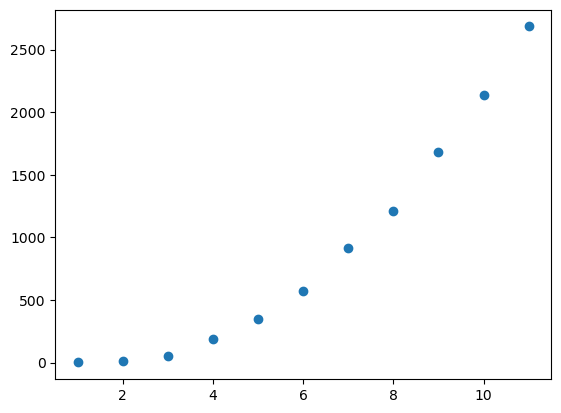

In [13]:
X = np.arange(2009,2020).reshape(-1,1) - 2008

#双十一销量(亿元)
y = np.array([0.5,9.36,52,191,350,571,912,1207,1682,2135,2684])
display(X,y)

plt.scatter(X,y)

In [14]:
X_test = np.linspace(2009,2020,50).reshape(-1,1) - 2008

In [15]:
poly = PolynomialFeatures(degree=2,interaction_only=False)
X_2 = poly.fit_transform(X)

display(X_2)

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.],
       [  1.,  11., 121.]])

In [16]:
model = LinearRegression(fit_intercept = False)
model.fit(X_2,y)

,fit_intercept,False
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
X_test2 = poly.fit_transform(X_test)

In [18]:
y_pred = model.predict(X_test2)

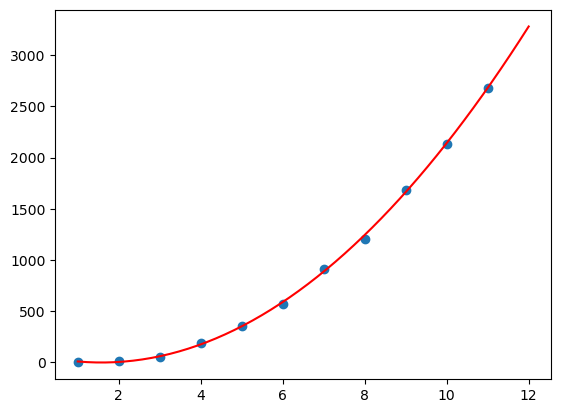

In [19]:
plt.scatter(X,y)
plt.plot(X_test,y_pred,'red')

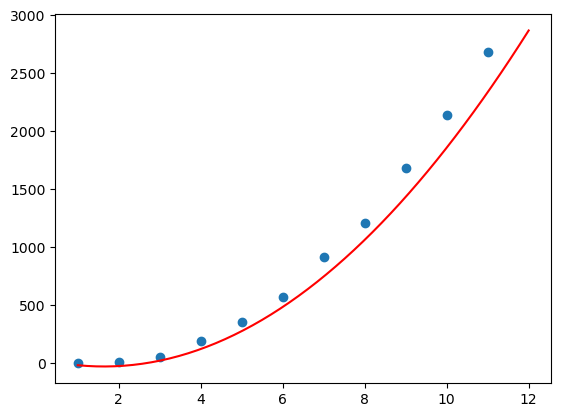

In [24]:
poly = PolynomialFeatures(degree=2,interaction_only=False)
X_2 = poly.fit_transform(X)

standard = StandardScaler()
X_2_norm = standard.fit_transform(X_2)

model = SGDRegressor(max_iter=10000,eta0=0.5)
model.fit(X_2_norm,y)

X_test2 = poly.fit_transform(X_test)
X_test2_norm = standard.fit_transform(X_test2)
y_pred = model.predict(X_test2_norm)

plt.scatter(X,y)
plt.plot(X_test,y_pred,'red')